# 03 — Repetición de compra

Este notebook responde a seis preguntas sobre repetición de compra y
comportamiento por canal/campaña/dispositivo, usando la base ya limpia
(`/data/processed/civitatis.duckdb`, generada por `python -m src.limpieza`
y `python -m src.metricas`).

Cada pregunta se responde con una consulta SQL separada.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import plotly.express as px

from src import conexion

con = conexion.connect_processed()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## 1. % de clientes recurrentes por canal

Para cada canal de `reservas_limpias`, de todos los clientes que han
reservado alguna vez por ese canal (reservas no canceladas), qué % son
recurrentes según `clientes_recurrentes` (2 o más reservas no canceladas,
en cualquier canal). Un mismo cliente puede contar en varios canales si ha
reservado por más de uno.

In [2]:
recurrencia_canal = con.execute('''
    WITH clientes_canal AS (
        SELECT DISTINCT canal, user_id
        FROM reservas_limpias
        WHERE estado != 'cancelada'
    )
    SELECT
        cc.canal,
        count(*) AS total_clientes,
        round(100.0 * sum(CASE WHEN cr.es_recurrente THEN 1 ELSE 0 END) / count(*), 2) AS pct_recurrencia
    FROM clientes_canal cc
    JOIN clientes_recurrentes cr ON cc.user_id = cr.user_id
    GROUP BY cc.canal
    ORDER BY pct_recurrencia DESC
''').df()
recurrencia_canal

,canal,total_clientes,pct_recurrencia
0,Email,427,44.96
1,Directo,847,33.77
2,SEO,1844,29.83
3,SEM,1146,27.75
4,Afiliados,439,25.74
5,Social,553,21.16


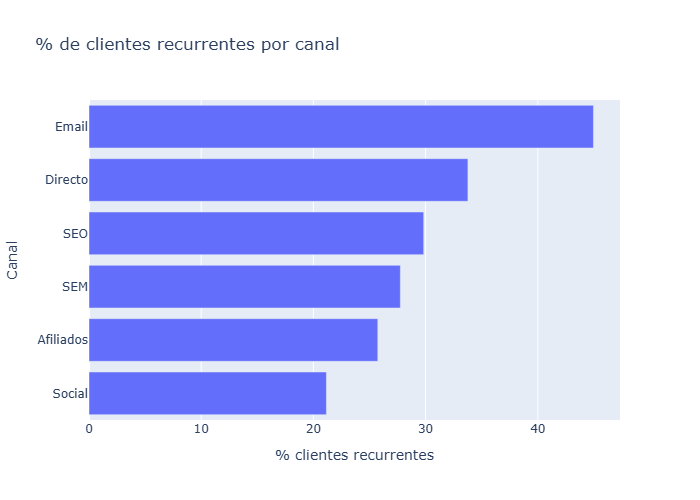

In [3]:
fig = px.bar(recurrencia_canal.sort_values('pct_recurrencia'),
             x='pct_recurrencia', y='canal', orientation='h',
             title='% de clientes recurrentes por canal',
             labels={'pct_recurrencia': '% clientes recurrentes', 'canal': 'Canal'})
fig.show(renderer="png")

**Email es el canal que más fideliza** (44,96% de sus clientes
son recurrentes), muy por delante del resto; **Social es el que menos**
(21,16%) — a más de 20 puntos de distancia.

## 2. % de clientes recurrentes por dispositivo dominante

Para cada cliente identificado (`user_id` no nulo) en `eventos_con_id`, se
calcula cuál es su `device` más frecuente (dispositivo dominante) y se cruza
con `clientes_recurrentes` para ver el % de recurrencia en cada grupo.

In [4]:
recurrencia_dispositivo = con.execute('''
    WITH eventos_dispositivo AS (
        SELECT user_id, device, count(*) AS n_eventos
        FROM eventos_con_id
        WHERE user_id IS NOT NULL
        GROUP BY user_id, device
    ),
    dispositivo_dominante AS (
        SELECT user_id, device AS dispositivo_dominante
        FROM (
            SELECT user_id, device, n_eventos,
                   row_number() OVER (PARTITION BY user_id ORDER BY n_eventos DESC, device) AS rn
            FROM eventos_dispositivo
        )
        WHERE rn = 1
    )
    SELECT
        dd.dispositivo_dominante,
        count(*) AS total_clientes,
        round(100.0 * sum(CASE WHEN cr.es_recurrente THEN 1 ELSE 0 END) / count(*), 2) AS pct_recurrencia
    FROM dispositivo_dominante dd
    JOIN clientes_recurrentes cr ON dd.user_id = cr.user_id
    GROUP BY dd.dispositivo_dominante
    ORDER BY pct_recurrencia DESC
''').df()
recurrencia_dispositivo

,dispositivo_dominante,total_clientes,pct_recurrencia
0,desktop,2167,30.23
1,mobile,2778,30.13
2,tablet,301,27.91


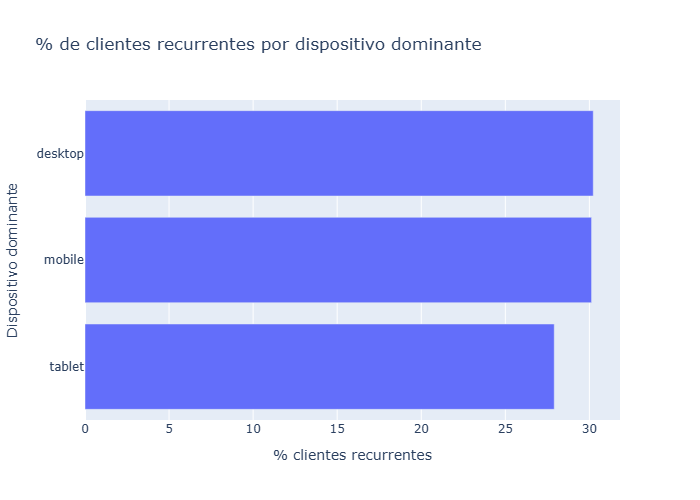

In [5]:
fig = px.bar(recurrencia_dispositivo.sort_values('pct_recurrencia'),
             x='pct_recurrencia', y='dispositivo_dominante', orientation='h',
             title='% de clientes recurrentes por dispositivo dominante',
             labels={'pct_recurrencia': '% clientes recurrentes', 'dispositivo_dominante': 'Dispositivo dominante'})
fig.show(renderer="png")

**El dispositivo dominante casi no influye en si un cliente repite**:
desktop (30,23%), mobile (30,13%) y tablet (27,91%) están a menos de 3 puntos
entre sí — a diferencia del canal (pregunta 1), aquí no hay un grupo que
destaque.

## 3. % de sesiones con user_id vs. sin user_id

De todas las sesiones de `eventos_con_id`, qué % corresponde a un cliente
conocido (algún evento de la sesión trae `user_id` no nulo) frente a un
visitante desconocido (ningún evento de la sesión trae `user_id`).

In [6]:
sesiones_identificadas = con.execute('''
    WITH sesiones_id AS (
        SELECT session_id, bool_or(user_id IS NOT NULL) AS tiene_user_id
        FROM eventos_con_id
        GROUP BY session_id
    )
    SELECT
        CASE WHEN tiene_user_id THEN 'con user_id (conocido)' ELSE 'sin user_id (desconocido)' END AS tipo_sesion,
        count(*) AS n_sesiones,
        round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct_sesiones
    FROM sesiones_id
    GROUP BY tiene_user_id
    ORDER BY tiene_user_id DESC
''').df()
sesiones_identificadas

,tipo_sesion,n_sesiones,pct_sesiones
0,con user_id (conocido),17686,6.49
1,sin user_id (desconocido),254844,93.51


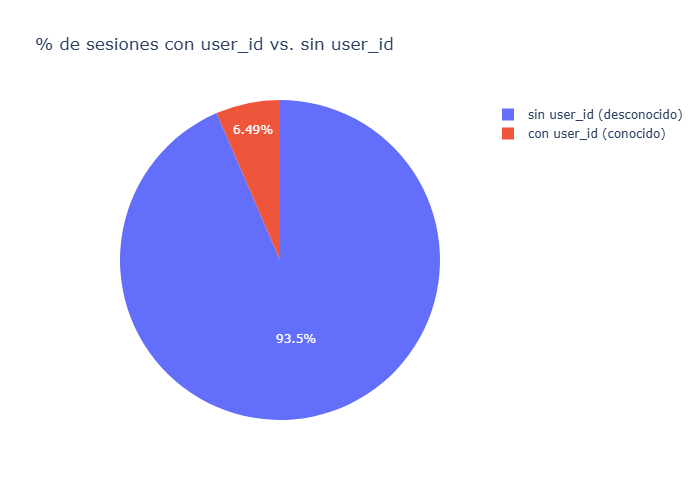

In [7]:
fig = px.pie(sesiones_identificadas, names='tipo_sesion', values='n_sesiones',
             title='% de sesiones con user_id vs. sin user_id')
fig.show(renderer="png")

**Solo el 6,49% de las sesiones pertenecen a un cliente identificado** — el
93,51% restante es tráfico anónimo. Coherente con lo visto en el notebook 01
(el grueso del tráfico web no está logueado).

## 4. Tasa de conversión por dispositivo dominante

Para cada sesión se calcula su dispositivo dominante (igual que en la
pregunta 2, pero a nivel sesión en vez de a nivel cliente) y se cruza con
`sesiones_con_conversion` para comparar la tasa de conversión entre mobile,
desktop y tablet.

In [8]:
conversion_dispositivo = con.execute('''
    WITH eventos_dispositivo_sesion AS (
        SELECT session_id, device, count(*) AS n_eventos
        FROM eventos_con_id
        GROUP BY session_id, device
    ),
    dispositivo_dominante_sesion AS (
        SELECT session_id, device AS dispositivo_dominante
        FROM (
            SELECT session_id, device, n_eventos,
                   row_number() OVER (PARTITION BY session_id ORDER BY n_eventos DESC, device) AS rn
            FROM eventos_dispositivo_sesion
        )
        WHERE rn = 1
    )
    SELECT
        dds.dispositivo_dominante,
        count(*) AS total_sesiones,
        round(100.0 * sum(CASE WHEN sc.convirtio THEN 1 ELSE 0 END) / count(*), 2) AS tasa_conversion_pct
    FROM dispositivo_dominante_sesion dds
    JOIN sesiones_con_conversion sc ON dds.session_id = sc.session_id
    GROUP BY dds.dispositivo_dominante
    ORDER BY tasa_conversion_pct DESC
''').df()
conversion_dispositivo

,dispositivo_dominante,total_sesiones,tasa_conversion_pct
0,desktop,67694,5.12
1,tablet,16254,2.82
2,mobile,188582,2.32


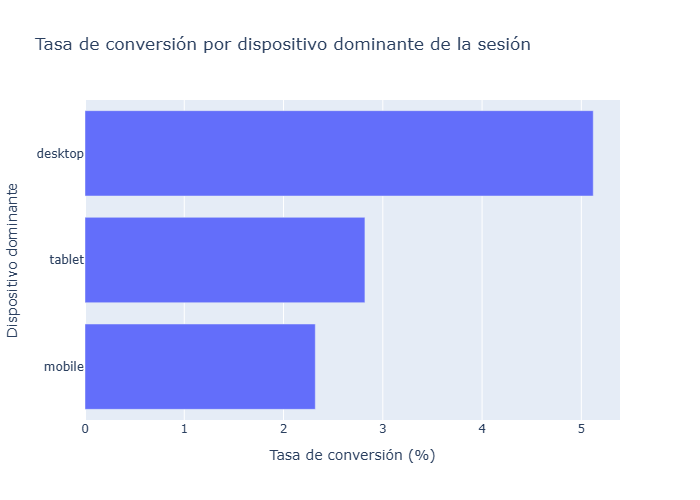

In [9]:
fig = px.bar(conversion_dispositivo.sort_values('tasa_conversion_pct'),
             x='tasa_conversion_pct', y='dispositivo_dominante', orientation='h',
             title='Tasa de conversión por dispositivo dominante de la sesión',
             labels={'tasa_conversion_pct': 'Tasa de conversión (%)', 'dispositivo_dominante': 'Dispositivo dominante'})
fig.show(renderer="png")

**Desktop convierte más del doble que mobile** (5,12% frente a 2,32%): a
diferencia del dispositivo dominante del cliente (pregunta 2, donde apenas
había diferencia en recurrencia), aquí sí hay una brecha grande — mobile trae
mucho tráfico pero le cuesta mucho más cerrar la compra.

In [10]:
conversion_dispositivo[['dispositivo_dominante', 'total_sesiones']].sort_values('total_sesiones', ascending=False)

,dispositivo_dominante,total_sesiones
2,mobile,188582
0,desktop,67694
1,tablet,16254


Tablet tiene 16.254 sesiones frente a las 188.582 de mobile y las 67.694 de
desktop — bastante menos volumen, por lo que conviene tenerlo en
cuenta como el grupo con menos sesiones detrás al comparar los tres.

## 5. Intervalo medio entre la 1ª y 2ª reserva de clientes recurrentes


In [11]:
intervalo_recompra = con.execute('''
    WITH reservas_ordenadas AS (
        -- Para cada reserva no cancelada de un cliente recurrente, numeramos
        -- sus reservas en orden cronológico (1ª, 2ª, 3ª...) con row_number(),
        -- y con LAG() traemos la fecha de la reserva inmediatamente anterior
        -- del mismo cliente (NULL si es la primera, porque no hay anterior).
        -- Se desempata por reserva_id: hay clientes con dos reservas en el
        -- mismo fecha_reserva exacto, y sin desempate el orden entre ellas
        -- no estaría garantizado de una ejecución a otra.
        SELECT
            r.user_id,
            r.fecha_reserva,
            row_number() OVER (PARTITION BY r.user_id ORDER BY r.fecha_reserva, r.reserva_id) AS n_reserva,
            LAG(r.fecha_reserva) OVER (PARTITION BY r.user_id ORDER BY r.fecha_reserva, r.reserva_id) AS fecha_reserva_anterior
        FROM reservas_limpias r
        -- Solo clientes recurrentes (2+ reservas no canceladas): son los
        -- únicos que tienen una "2ª reserva" que medir.
        JOIN clientes_recurrentes cr ON r.user_id = cr.user_id
        WHERE r.estado != 'cancelada' AND cr.es_recurrente
    )
    -- Nos quedamos solo con la fila n_reserva = 2 de cada cliente: ahí
    -- fecha_reserva_anterior es su 1ª reserva y fecha_reserva es su 2ª, así
    -- que date_diff() entre ambas da exactamente el intervalo 1ª -> 2ª.
    SELECT
        round(avg(date_diff('day', fecha_reserva_anterior, fecha_reserva)), 2) AS intervalo_medio_dias,
        count(*) AS n_clientes_recurrentes
    FROM reservas_ordenadas
    WHERE n_reserva = 2
''').df()
intervalo_recompra

,intervalo_medio_dias,n_clientes_recurrentes
0,47.7,1576


**Los clientes recurrentes tardan de media 47,7 días (casi 7 semanas) en
volver a reservar** tras su primera compra, sobre los 1.576 clientes
recurrentes de la base.

### Distribución del nº de reservas entre clientes recurrentes

El intervalo anterior solo mide el salto de la 1ª a la 2ª reserva. Aquí
vemos, de los clientes recurrentes (`clientes_recurrentes` con
`es_recurrente = true`), cuántas reservas no canceladas acumulan en total:
¿la mayoría se queda en 2, o hay un grupo relevante que llega a 3, 4 o
más?

In [12]:
distribucion_reservas_recurrentes = con.execute('''
    SELECT
        CASE WHEN reservas_no_canceladas >= 5 THEN '5+' ELSE CAST(reservas_no_canceladas AS VARCHAR) END AS n_reservas,
        count(*) AS n_clientes,
        round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct_clientes
    FROM clientes_recurrentes
    WHERE es_recurrente
    GROUP BY n_reservas
    ORDER BY n_reservas
''').df()
distribucion_reservas_recurrentes

,n_reservas,n_clientes,pct_clientes
0,2,1264,80.20
1,3,246,15.61
2,4,51,3.24
3,5+,15,0.95


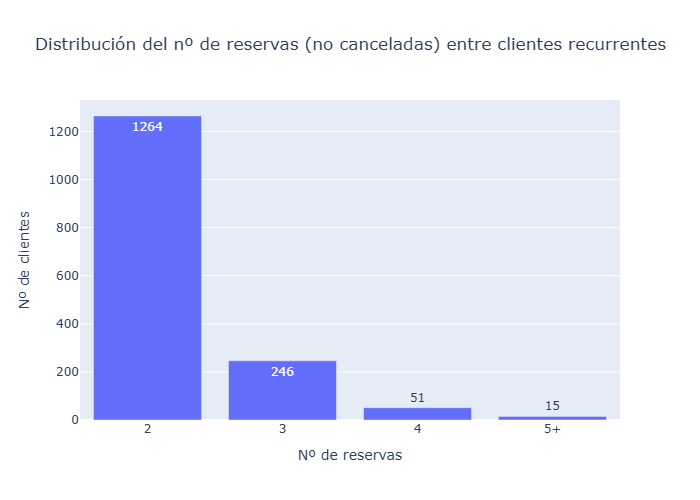

In [13]:
fig = px.bar(distribucion_reservas_recurrentes, x='n_reservas', y='n_clientes',
             title='Distribución del nº de reservas (no canceladas) entre clientes recurrentes',
             labels={'n_reservas': 'Nº de reservas', 'n_clientes': 'Nº de clientes'},
             text='n_clientes')
fig.show(renderer="png")

**La mayoría de los recurrentes repite solo una vez más.**
El 80,20% de los 1.576 clientes recurrentes tiene exactamente 2 reservas no
canceladas; solo el 15,61% llega a 3, y apenas un 4,19% (3,24% con 4 +
0,95% con 5, que es además el máximo observado) alcanza 4 o más reservas.

No hay un grupo grande de clientes "muy fieles" con muchas reservas — la
palanca de crecimiento no está en hacer comprar más a quien ya es fiel,
sino, en todo caso, en conseguir que ese 80% que se detiene en la 2ª reserva dé el salto a
una 3ª.

## 6. Influencia de campaña en recurrencia

`reservas_limpias.campana` solo se rellena cuando la reserva llega a través
de una campaña de marketing rastreada; el resto son reservas sin campaña
asociada. En vez de descartar esas filas,
se tratan como una categoría propia, `'sin campaña'` (vía
`COALESCE(campana, 'sin campaña')`), para no perder ese segmento del
análisis — como se ve abajo, es de hecho el grupo más numeroso.

In [14]:
pct_campana_null = con.execute('''
    SELECT
        round(100.0 * sum(CASE WHEN campana IS NULL THEN 1 ELSE 0 END) / count(*), 2) AS pct_campana_null,
        sum(CASE WHEN campana IS NULL THEN 1 ELSE 0 END) AS n_campana_null,
        count(*) AS total_reservas
    FROM reservas_limpias
''').df()
pct_campana_null

,pct_campana_null,n_campana_null,total_reservas
0,61.12,5124.0,8384


**El 61,12% de las reservas (5.124 de 8.384) no tienen campaña asociada** —
es, con diferencia, la categoría más grande, así que se incluye como
`'sin campaña'` en el análisis en vez de excluirla.

In [15]:
recurrencia_campana = con.execute('''
    WITH clientes_campana AS (
        SELECT DISTINCT COALESCE(campana, 'sin campaña') AS campana, user_id
        FROM reservas_limpias
        WHERE estado != 'cancelada'
    )
    SELECT
        cc.campana,
        count(*) AS total_clientes,
        round(100.0 * sum(CASE WHEN cr.es_recurrente THEN 1 ELSE 0 END) / count(*), 2) AS pct_recurrencia
    FROM clientes_campana cc
    JOIN clientes_recurrentes cr ON cc.user_id = cr.user_id
    GROUP BY cc.campana
    ORDER BY pct_recurrencia DESC
''').df()
recurrencia_campana

,campana,total_clientes,pct_recurrencia
0,newsletter_semanal,176,64.77
1,post_compra_crossell,196,57.65
2,black_friday,61,57.38
3,carrito_abandonado,195,56.41
4,generic_tours_es,291,43.99
5,brand_es,272,42.65
6,retargeting_q1,288,37.85
7,comparador_ocio,177,37.85
8,generic_tours_latam,297,37.71
9,blog_viajeros,178,36.52


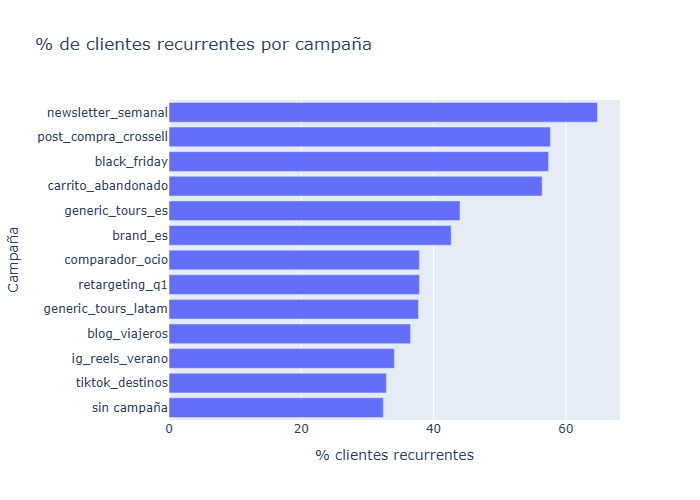

In [16]:
fig = px.bar(recurrencia_campana.sort_values('pct_recurrencia'),
             x='pct_recurrencia', y='campana', orientation='h',
             title='% de clientes recurrentes por campaña',
             labels={'pct_recurrencia': '% clientes recurrentes', 'campana': 'Campaña'})
fig.show(renderer="png")

**El tamaño de muestra varía mucho entre campañas** — desde 3.296 clientes
en `sin campaña` hasta solo 61 en `black_friday`. Todas las
nombradas tienen menos de 300 clientes, así que sus porcentajes de
recurrencia hay que leerlos con cautela: en una campaña tan pequeña, un
puñado de clientes de más o de menos mueve el porcentaje varios puntos.

In [17]:
# Un cliente recurrente puede tener reservas de ambos tipos (con y sin
# campaña), así que "sin campaña" y "alguna campaña" no son excluyentes:
# aquí medimos, sobre el total de clientes recurrentes, qué % tiene al
# menos una reserva de cada tipo.
recurrentes_sin_campana_vs_con_campana = con.execute('''
    SELECT
        count(DISTINCT CASE WHEN r.campana IS NULL THEN r.user_id END)     AS recurrentes_con_reserva_sin_campana,
        count(DISTINCT CASE WHEN r.campana IS NOT NULL THEN r.user_id END) AS recurrentes_con_alguna_campana,
        count(DISTINCT r.user_id)                                         AS total_recurrentes,
        round(100.0 * count(DISTINCT CASE WHEN r.campana IS NULL THEN r.user_id END) / count(DISTINCT r.user_id), 2) AS pct_con_reserva_sin_campana,
        round(100.0 * count(DISTINCT CASE WHEN r.campana IS NOT NULL THEN r.user_id END) / count(DISTINCT r.user_id), 2) AS pct_con_alguna_campana
    FROM reservas_limpias r
    JOIN clientes_recurrentes cr ON r.user_id = cr.user_id
    WHERE r.estado != 'cancelada' AND cr.es_recurrente
''').df()
recurrentes_sin_campana_vs_con_campana

,recurrentes_con_reserva_sin_campana,recurrentes_con_alguna_campana,total_recurrentes,pct_con_reserva_sin_campana,pct_con_alguna_campana
0,1068,716,1576,67.77,45.43




**Las 4 campañas con mejor recurrencia** (todas por encima del 56%):

- `newsletter_semanal` — 64,77%
- `post_compra_crossell` — 57,65%
- `black_friday` — 57,38%
- `carrito_abandonado` — 56,41%

- Las 4 son campañas de **retención**: se dirigen a gente que ya había 
  comprado antes (newsletter a suscriptores, post-compra a quien ya 
  reservó, black friday a base de clientes existente...).

- Ninguna busca captar clientes completamente nuevos — por eso no es 
  casualidad que fidelicen mejor que sin campañas o que campañas 
  de captación como `tiktok_destinos` (32,86%) o `ig_reels_verano` 
  (34,07%), que sí buscan gente que nunca ha comprado.

- Sin embargo, el 67,77% de los clientes recurrentes tiene también alguna reserva sin campaña en su historial — el tráfico sin campaña sigue siendo el origen más habitual en volumen, aunque no el que mejor convierte en fidelidad."


**Aviso importante:**
- Varias de estas campañas tienen pocos clientes (algunas por 
  debajo de 300, alguna con solo 61). Con tan poca muestra, el porcentaje 
  puede moverse varios puntos solo por casualidad.

- Por eso esta lectura se trata como una tendencia razonable, no como una 
  conclusión cerrada — habría que confirmarla cuando haya más volumen de 
  datos.

## Conclusiones finales

1. **El canal de adquisición sí predice fidelización, el dispositivo no.**
   El % de clientes recurrentes varía muchísimo por canal (44,96% en Email
   frente a 21,16% en Social, más de 20 puntos de diferencia), pero apenas
   varía por dispositivo dominante (28-30% en los tres). De invertir en retención, 
   el canal es la palanca que importa, no el dispositivo.

2. **El tráfico mobile es mayoritario pero convierte peor.** Mobile
   representa la mayor parte de las sesiones, pero su tasa de conversión
   (2,32%) es menos de la mitad que la de desktop (5,12%). Con un 93,51% de
   sesiones totalmente anónimas (sin `user_id`), por lo que hay mucho margen para
   mejorar tanto la experiencia de compra en mobile como la identificación
   de visitantes.

3. **La ventana de recompra es de ~7 semanas.** Los clientes recurrentes
   tardan de media 47,7 días en hacer su 2ª reserva. Es un buen punto de
   referencia para programar campañas de reactivación (p. ej. por email, el
   canal que mejor fideliza) dirigidas a clientes que ya pasaron ese plazo
   sin volver a comprar.

### Sobre "experiencia de compra" como factor de repetición

El enunciado sugiere "experiencia de compra" como posible factor de 
repetición, pero el dataset no contiene ninguna señal directa de 
experiencia (valoraciones, encuestas de satisfacción, tiempos de carga, 
errores de checkout, incidencias de atención al cliente). 